In [1]:
%load_ext autoreload
%autoreload 2

In [147]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import statsmodels.api as sm
from scipy.stats import nbinom
from tqdm import tqdm

import torch
import torch_geometric as pyg

from bipartite_gnn.train_test import GNNTrainer
from baseline_evals.feature_selection import variance_filtering

In [3]:
null_vals = ["NA"]
mrna = pl.read_csv("BRCA_PROCESSED_DATA/mrna.tsv", separator="\t", null_values=null_vals)
cna = pl.read_csv("BRCA_PROCESSED_DATA/cnvth.tsv", separator="\t", null_values=null_vals)
mirna = pl.read_csv("BRCA_PROCESSED_DATA/mirna.tsv", separator="\t", null_values=null_vals)

labels = pl.read_csv("BRCA_PROCESSED_DATA/labels.tsv", separator="\t")
le = LabelEncoder()
le.fit(labels["PAM50_mRNA_nature2012"].to_list())
y = le.transform(labels["PAM50_mRNA_nature2012"].to_list())
# labels, y

In [4]:
# mrna, cna, mirna
mrna_gene_names = mrna[:, 0].to_list()
cna_gene_names = cna[:, 0].to_list()
mirna_gene_names = mirna[:, 0].to_list()

In [5]:
mrna_X = torch.tensor(mrna[:, 1:].to_numpy().T)
cna_X = torch.tensor(cna[:, 1:].to_numpy().T)
mirna_X = torch.tensor(mirna[:, 1:].to_numpy().T)

In [6]:
mrna_X.shape

torch.Size([483, 18975])

In [160]:
select_mask = variance_filtering(mrna_X, 10000)

mrna_X_1000 = mrna_X[:, select_mask]

In [180]:
import warnings
from statsmodels.tools.sm_exceptions import HessianInversionWarning

def differential_exp_nbnm(expression_vector, var_multiplier=1):
    """
    Estimate the differential expression of a gene using the negative binomial distribution.

    Args:
        expression_vector (np.ndarray): The expression vector of the gene.
        var_multiplier (int): The multiplier for the variance threshold. Default is 1.
    Returns:
        select_mask (np.ndarray): The mask of the selected samples.
    """
    if not isinstance(expression_vector, np.ndarray):
        expression_vector = np.array(expression_vector)

    # ignore all warnings
    with warnings.catch_warnings():
        # for some distributions, the fitting will fail, so ignore warnings for those
        warnings.filterwarnings("ignore")
        res = sm.NegativeBinomial(expression_vector, np.ones_like(expression_vector)).fit(start_params=[1, 1], disp=0)

    mu = np.exp(res.params[0])
    p = 1 / (1 + mu * res.params[1])
    r = mu * p / (1 - p)

    var = r * (1-p) / p**2
    # var = np.sqrt(var)
    # std = var # np.sqrt(var)
    mask_above = expression_vector > mu + var * var_multiplier
    mask_below = expression_vector < mu - var * var_multiplier

    return mask_below, mask_above

In [182]:
edges = 0
disconnected_nodes = 0

under_expressed = 0
over_expressed = 0

input = mrna_X

for i in tqdm(range(input.shape[1])):
   mask_below, mask_above = differential_exp_nbnm(input[:, i])

   under_expressed += np.sum(mask_below)
   over_expressed += np.sum(mask_above)

   edges_this_node = np.sum(mask_below) + np.sum(mask_above)

   if edges_this_node == 0:
       disconnected_nodes += 1
   edges += edges_this_node

print(f"Under-expressed: {under_expressed}, Over-expressed: {over_expressed}")
print(f"Edges: {edges}, Disconnected nodes: {disconnected_nodes}")

  0%|          | 0/18975 [00:00<?, ?it/s]

100%|██████████| 18975/18975 [01:12<00:00, 260.47it/s]

Under-expressed: 0, Over-expressed: 199894
Edges: 199894, Disconnected nodes: 13807


In [169]:
10863 / 483

22.490683229813666

0.2760287784679089 0.41730886350147534
Optimization terminated successfully.
         Current function value: 0.614659
         Iterations: 22
         Function evaluations: 23
         Gradient evaluations: 23


/home/lubojjan/micromamba/envs/diploma/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:3739: RuntimeWarning: invalid value encountered in log
  start_params[-1] = np.log(start_params[-1])


                     NegativeBinomial Regression Results                      
Dep. Variable:                      y   No. Observations:                  483
Model:               NegativeBinomial   Df Residuals:                      482
Method:                           MLE   Df Model:                            0
Date:                Wed, 03 Apr 2024   Pseudo R-squ.:                     nan
Time:                        14:37:05   Log-Likelihood:                -296.88
converged:                       True   LL-Null:                           nan
Covariance Type:            nonrobust   LLR p-value:                       nan
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.2872        nan        nan        nan         nan         nan
alpha       1.957e-05        nan        nan        nan         nan         nan
mu: 0.2760301193398227, var: 0.2760316101058642 , p:

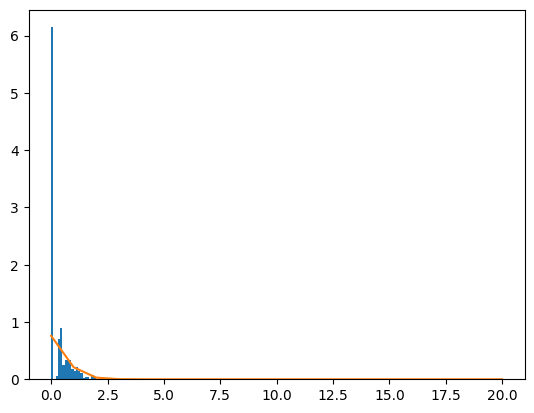

In [127]:
from torch import norm


input = np.array(mrna_X[:, 8])

print(input.mean(), input.std())

res = sm.NegativeBinomial(np.array(input), np.ones_like(input)).fit(start_params=[1, 1])
print(res.summary())

mu = np.exp(res.params[0])
p = 1 / (1 + mu * res.params[1])
r = mu * p / (1 - p)

# p = 0.25
# r = 3

var = r * (1-p) / p**2
std = np.sqrt(var)


print(f"mu: {mu}, var: {var} , p: {p}, r: {r}")

_ = plt.hist(input, bins=20, density=True)
x_plot = np.linspace(0, 20, 21)
plt.plot(x_plot, nbinom.pmf(x_plot, r, p))

In [128]:
np.sqrt(0.27)

0.5196152422706632

In [40]:
mu = (r*(1-p)) / p
var = (r*(1-p)) / p**2

mu, np.sqrt(var)

(0.2760287784679089, 57.84359276103158)

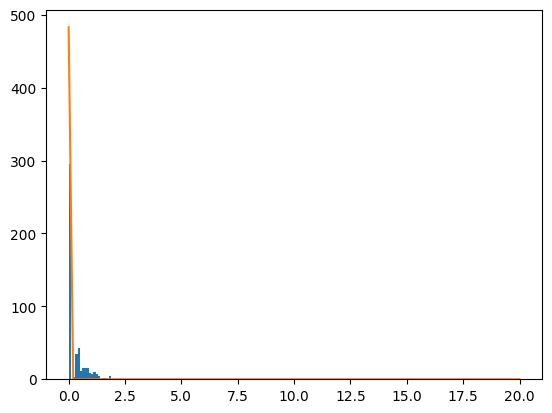

In [46]:
# create hetero-data object
data = pyg.data.HeteroData()

proj_dim = 128

# sample node features
data["mrna"].x = mrna_X
data["cna"].x = cna_X
data["mirna"].x = mirna_X
data["mrna"].y = data["cna"].y = data["mirna"].y = torch.tensor(y)

# feature node projection
data["mrna_feature"].x = torch.ones(mrna_X.shape[1], proj_dim)
data["cna_feature"].x = torch.ones(cna_X.shape[1], proj_dim)
data["mirna_feature"].x = torch.ones(mirna_X.shape[1], proj_dim)

dh = data.to_homogeneous()

In [47]:
data

HeteroData(
  mrna={
    x=[483, 18975],
    y=[483],
  },
  cna={
    x=[483, 24776],
    y=[483],
  },
  mirna={
    x=[483, 231],
    y=[483],
  },
  mrna_feature={ x=[18975, 128] },
  cna_feature={ x=[24776, 128] },
  mirna_feature={ x=[231, 128] }
)

In [48]:
mrna_X.shape, cna_X.shape, mirna_X.shape

(torch.Size([483, 18975]), torch.Size([483, 24776]), torch.Size([483, 231]))

In [49]:
dh

Data(x=[45431, 24776], y=[45431], node_type=[45431])

In [50]:
# get counts of unique values in the dh.node_type tensor
node_type_counts = torch.unique(dh.node_type, return_counts=True)
node_type_counts

(tensor([0, 1, 2, 3, 4, 5]),
 tensor([  483,   483,   483, 18975, 24776,   231]))

In [19]:
data

HeteroData(
  mrna={
    x=[18975, 483],
    y=[483],
  },
  cna={
    x=[24776, 483],
    y=[483],
  },
  mirna={
    x=[231, 483],
    y=[483],
  }
)

In [ ]:
# train the model